### Introduction

This project builds an image classification model to identify **bleached** and **healthy** corals using deep learning.

### Project Goals
- Detect coral bleaching status from underwater coral images.
- Compare transfer learning performance between **ResNet50** and **EfficientNetB0**.
- Evaluate model quality using accuracy, loss curves, confusion matrix, and classification metrics.

### Dataset
The dataset is organized into two classes:
- `bleached_corals/`
- `healthy_corals/`

### Workflow Overview
1. Load libraries and define configuration parameters.
2. Perform exploratory data analysis (EDA).
3. Prepare train/validation/test splits.
4. Train and evaluate transfer learning models.
5. Compare final model performance and results.

In [13]:
# ==============================================================
# Coral Health Classification (Bleached vs Healthy)
# Using Transfer Learning: ResNet50 & EfficientNetB0
#
# Dataset structure:
# ├── bleached_corals/   (485 images)
# ├── healthy_corals/    (483 images)
# ==============================================================

import os
import random
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as effnet_preprocess
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
# ==============================================================
# 1. SETUP & PARAMETERS
# ==============================================================

DATA_DIR = "./"   # Change this to your dataset path if needed
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

bleached_dir = os.path.join(DATA_DIR, "bleached_corals")
healthy_dir = os.path.join(DATA_DIR, "healthy_corals")

Bleached coral images: 485
Healthy coral images: 438


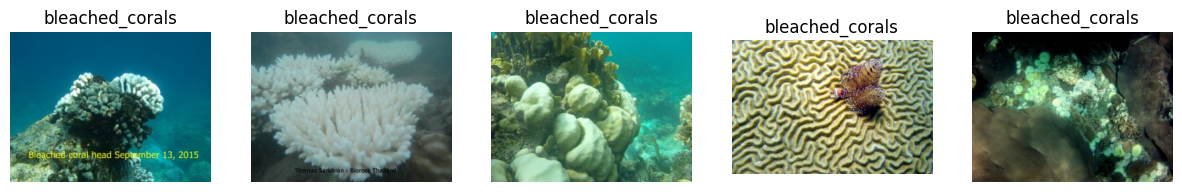

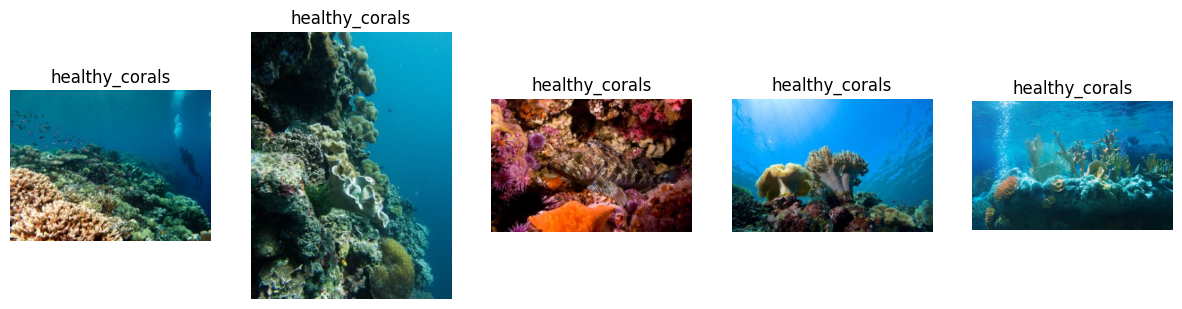

C:\Users\Thiwanka\AppData\Local\Temp\ipykernel_11624\3857300560.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=labels, palette="coolwarm")


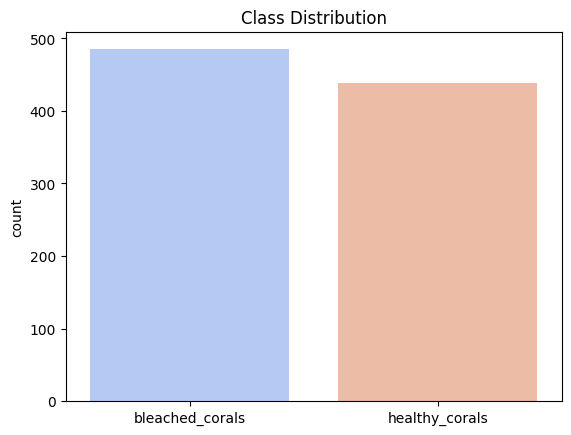

In [3]:
# ==============================================================
# 2. EXPLORATORY DATA ANALYSIS (EDA)
# ==============================================================

bleached_images = os.listdir(bleached_dir)
healthy_images = os.listdir(healthy_dir)
print(f"Bleached coral images: {len(bleached_images)}")
print(f"Healthy coral images: {len(healthy_images)}")

# Plot few random samples
def show_samples(class_name, path, n=5):
    class_path = os.path.join(path, class_name)
    sample_files = random.sample(os.listdir(class_path), n)
    plt.figure(figsize=(15, 5))
    for i, file in enumerate(sample_files):
        img = Image.open(os.path.join(class_path, file))
        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")
    plt.show()

show_samples("bleached_corals", DATA_DIR)
show_samples("healthy_corals", DATA_DIR)

# Class distribution
labels = ["bleached_corals"] * len(bleached_images) + ["healthy_corals"] * len(healthy_images)
sns.countplot(x=labels, palette="coolwarm")
plt.title("Class Distribution")
plt.show()

### EDA Summary

The exploratory data analysis (EDA) step helps verify dataset quality before model training. In this notebook, EDA is used to inspect sample coral images and check class distribution between **bleached_corals** and **healthy_corals**.

From the visual inspection, images show realistic underwater variation in lighting, angle, and texture, which can affect model learning. The class count plot indicates the two classes are nearly balanced, reducing the risk of model bias toward one class.

These EDA findings support the next step of creating train, validation, and test splits, then applying data augmentation to improve model generalization.

In [4]:
# ==============================================================
# 3. TRAIN-VALIDATION-TEST SPLIT
# ==============================================================

# Create dataframe for generator
data = []
for label, folder in enumerate(["bleached_corals", "healthy_corals"]):
    folder_path = os.path.join(DATA_DIR, folder)
    for img_name in os.listdir(folder_path):
        data.append((os.path.join(folder_path, img_name), folder))

df = pd.DataFrame(data, columns=["filepath", "label"])
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=SEED)
train_df, val_df = train_test_split(train_df, test_size=0.2, stratify=train_df["label"], random_state=SEED)

print("Train:", train_df.shape, "Validation:", val_df.shape, "Test:", test_df.shape)

Train: (590, 2) Validation: (148, 2) Test: (185, 2)


In [5]:
# ==============================================================
# 4. DATA AUGMENTATION & DATA GENERATORS
# ==============================================================

train_datagen_resnet = ImageDataGenerator(
    preprocessing_function=resnet_preprocess,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen_resnet = ImageDataGenerator(preprocessing_function=resnet_preprocess)
test_datagen_resnet = ImageDataGenerator(preprocessing_function=resnet_preprocess)

train_gen_resnet = train_datagen_resnet.flow_from_dataframe(
    train_df, x_col="filepath", y_col="label", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="binary", seed=SEED)

val_gen_resnet = val_datagen_resnet.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="binary", seed=SEED)

test_gen_resnet = test_datagen_resnet.flow_from_dataframe(
    test_df, x_col="filepath", y_col="label", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="binary", shuffle=False)

Found 590 validated image filenames belonging to 2 classes.
Found 148 validated image filenames belonging to 2 classes.
Found 185 validated image filenames belonging to 2 classes.


### Why Data Augmentation Was Used

Data augmentation was applied to improve model generalization and reduce overfitting during training. Coral images can vary due to underwater lighting, camera angle, orientation, and distance, so the model needs to learn robust features instead of memorizing fixed patterns.

By introducing realistic transformations such as rotation, shifts, zoom, and horizontal flips, the training set becomes more diverse without collecting new images. This helps the ResNet50 model perform better on unseen validation and test data.

In [6]:
# ==============================================================
# 5. TRAIN RESNET50 MODEL
# ==============================================================

base_resnet = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
for layer in base_resnet.layers[:-20]:
    layer.trainable = False

model_resnet = Sequential([
    base_resnet,
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(1, activation="sigmoid")
])

model_resnet.compile(optimizer=Adam(1e-4), loss="binary_crossentropy", metrics=["accuracy"])
history_resnet = model_resnet.fit(
    train_gen_resnet, validation_data=val_gen_resnet, epochs=10
)

Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 39s 2s/step - accuracy: 0.6424 - loss: 0.6473 - val_accuracy: 0.8041 - val_loss: 0.4468
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.7746 - loss: 0.4620 - val_accuracy: 0.8243 - val_loss: 0.3904
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.8186 - loss: 0.4088 - val_accuracy: 0.8446 - val_loss: 0.3959
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 32s 2s/step - accuracy: 0.8593 - loss: 0.3028 - val_accuracy: 0.8446 - val_loss: 0.4225
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.8763 - loss: 0.2465 - val_accuracy: 0.8514 - val_loss: 0.4192
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9220 - loss: 0.1958 - val_accuracy: 0.8378 - val_loss: 0.5295
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9441 - loss: 0.1491 - val_accuracy: 0.7973 - val_loss: 0.6452
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 33s 2s/step - accuracy: 0.9508 - loss: 0.1325 - val_accuracy: 0.8378 - val_loss:

In [8]:
# ==============================================================
# 6. TRAIN EFFICIENTNETB0 MODEL
# ==============================================================

train_datagen_effnet = ImageDataGenerator(
    preprocessing_function=effnet_preprocess,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen_effnet = ImageDataGenerator(preprocessing_function=effnet_preprocess)
test_datagen_effnet = ImageDataGenerator(preprocessing_function=effnet_preprocess)

train_gen_effnet = train_datagen_effnet.flow_from_dataframe(
    train_df, x_col="filepath", y_col="label", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="binary", seed=SEED)

val_gen_effnet = val_datagen_effnet.flow_from_dataframe(
    val_df, x_col="filepath", y_col="label", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="binary", seed=SEED)

test_gen_effnet = test_datagen_effnet.flow_from_dataframe(
    test_df, x_col="filepath", y_col="label", target_size=IMG_SIZE,
    batch_size=BATCH_SIZE, class_mode="binary", shuffle=False)

base_effnet = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
for layer in base_effnet.layers[:-20]:
    layer.trainable = False

model_effnet = Sequential([
    base_effnet,
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(1, activation="sigmoid")
])

model_effnet.compile(optimizer=Adam(1e-4), loss="binary_crossentropy", metrics=["accuracy"])
history_effnet = model_effnet.fit(
    train_gen_effnet, validation_data=val_gen_effnet, epochs=10
)

Found 590 validated image filenames belonging to 2 classes.
Found 148 validated image filenames belonging to 2 classes.


Found 185 validated image filenames belonging to 2 classes.
Epoch 1/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step - accuracy: 0.5644 - loss: 0.6769 - val_accuracy: 0.6892 - val_loss: 0.5965
Epoch 2/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 935ms/step - accuracy: 0.6983 - loss: 0.5879 - val_accuracy: 0.7162 - val_loss: 0.5452
Epoch 3/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 936ms/step - accuracy: 0.7356 - loss: 0.5483 - val_accuracy: 0.7770 - val_loss: 0.5101
Epoch 4/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 937ms/step - accuracy: 0.7390 - loss: 0.5162 - val_accuracy: 0.7838 - val_loss: 0.4823
Epoch 5/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 17s 920ms/step - accuracy: 0.7678 - loss: 0.4761 - val_accuracy: 0.7973 - val_loss: 0.4609
Epoch 6/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 952ms/step - accuracy: 0.7763 - loss: 0.4686 - val_accuracy: 0.8378 - val_loss: 0.4446
Epoch 7/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 18s 936ms/step - accuracy: 0.8085 - loss: 0.4483 - val_accuracy: 0.8243 - val_loss: 0.4295
Epoch 8/10
19/19 ━━━━━━━━━━━━━━━━━━━━ 19

In [9]:
# ==============================================================
# 7. EVALUATION ON TEST SET
# ==============================================================

resnet_eval = model_resnet.evaluate(test_gen_resnet)
effnet_eval = model_effnet.evaluate(test_gen_effnet)

print(f"\nResNet50 Test Accuracy: {resnet_eval[1]:.4f}")
print(f"EfficientNetB0 Test Accuracy: {effnet_eval[1]:.4f}")

6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7946 - loss: 1.1241
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 604ms/step - accuracy: 0.8054 - loss: 0.4157

ResNet50 Test Accuracy: 0.7946
EfficientNetB0 Test Accuracy: 0.8054


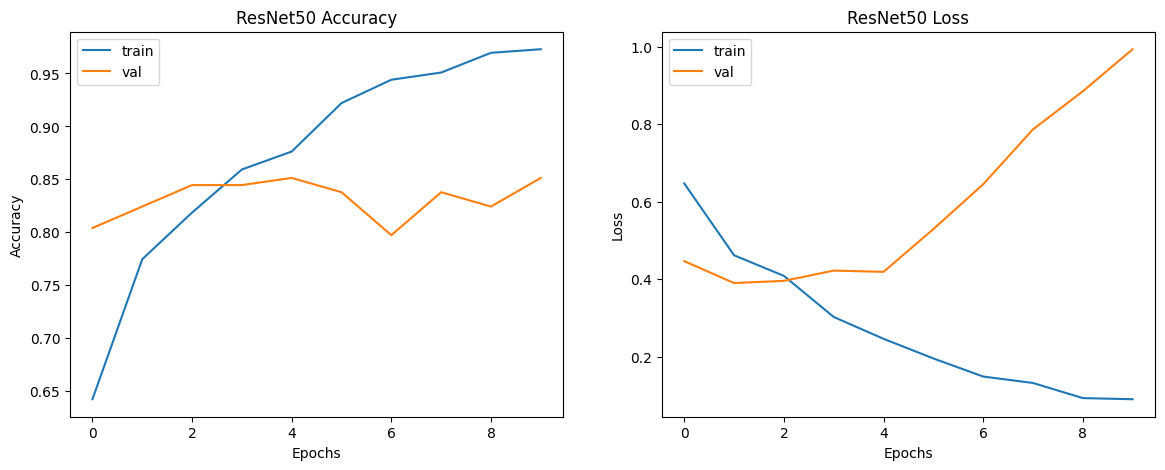

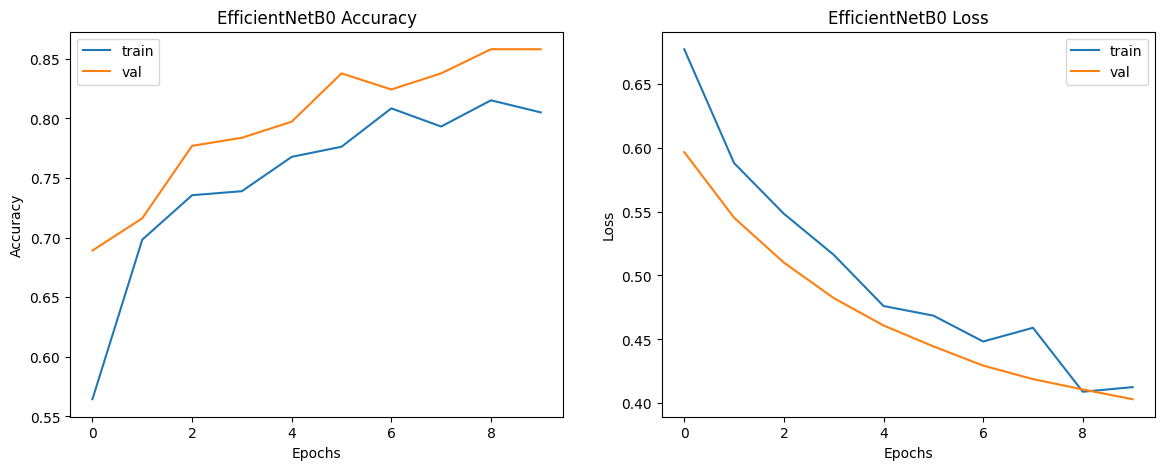

In [10]:
# ==============================================================
# 8. PLOT TRAINING HISTORY
# ==============================================================

def plot_history(history, title):
    plt.figure(figsize=(14,5))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='train')
    plt.plot(history.history['val_accuracy'], label='val')
    plt.title(f'{title} Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='train')
    plt.plot(history.history['val_loss'], label='val')
    plt.title(f'{title} Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_history(history_resnet, "ResNet50")
plot_history(history_effnet, "EfficientNetB0")

In [11]:
# ==============================================================
# 9. COMPARISON SUMMARY
# ==============================================================

results = pd.DataFrame({
    "Model": ["ResNet50", "EfficientNetB0"],
    "Test Accuracy": [resnet_eval[1], effnet_eval[1]],
    "Test Loss": [resnet_eval[0], effnet_eval[0]]
})
print(results)

            Model  Test Accuracy  Test Loss
0        ResNet50       0.794595   1.124142
1  EfficientNetB0       0.805405   0.415714


6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step


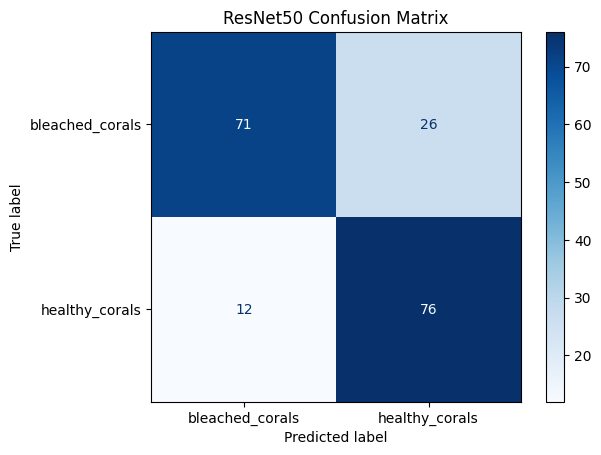


Classification Report for ResNet50:
                 precision    recall  f1-score   support

bleached_corals       0.86      0.73      0.79        97
 healthy_corals       0.75      0.86      0.80        88

       accuracy                           0.79       185
      macro avg       0.80      0.80      0.79       185
   weighted avg       0.80      0.79      0.79       185

6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 901ms/step


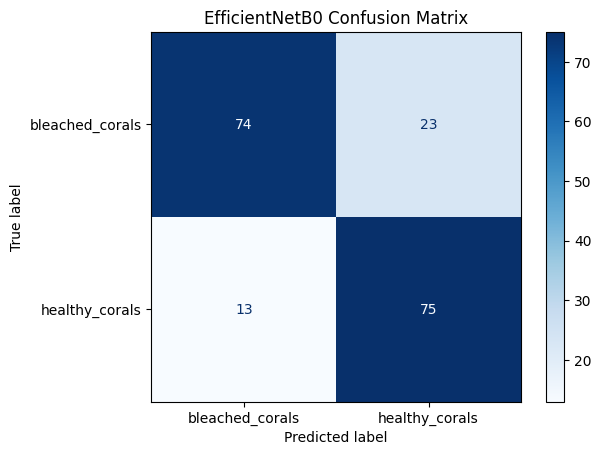


Classification Report for EfficientNetB0:
                 precision    recall  f1-score   support

bleached_corals       0.85      0.76      0.80        97
 healthy_corals       0.77      0.85      0.81        88

       accuracy                           0.81       185
      macro avg       0.81      0.81      0.81       185
   weighted avg       0.81      0.81      0.81       185



In [14]:
# ==============================================================
# 10. CONFUSION MATRIX & CLASSIFICATION REPORT
# ==============================================================
def evaluate_model(model, test_gen, model_name):
    y_true = test_gen.classes
    class_labels = list(test_gen.class_indices.keys())
    y_pred = (model.predict(test_gen) > 0.5).astype(int).flatten()
    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(cmap='Blues')
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()
    print(f"\nClassification Report for {model_name}:")
    print(classification_report(y_true, y_pred, target_names=class_labels))
evaluate_model(model_resnet, test_gen_resnet, "ResNet50")
evaluate_model(model_effnet, test_gen_effnet, "EfficientNetB0")